## Corruption visualization

This notebook visualize the corruption types and it's severity (0: clean to 4: very corrupted)

This is the different types of corruption

1. Gaussian Noise
Simulates sensor noise
• mean = 0
• variance = controllable

2. Motion / Gaussian Blur
Simulates camera motion or focus issues

3. Occlusion (Cutout)
Random black square blocks
• simulate object obstruction

4. JPEG Compression Artifacts
Simulates low-quality image transmission
• quality factor: 10 → 100

5. Brightness / Contrast shift (optional upgrade)
• Simulates lighting conditions

6. Image augmentation
• Make some random rotations on images

Files already downloaded and verified


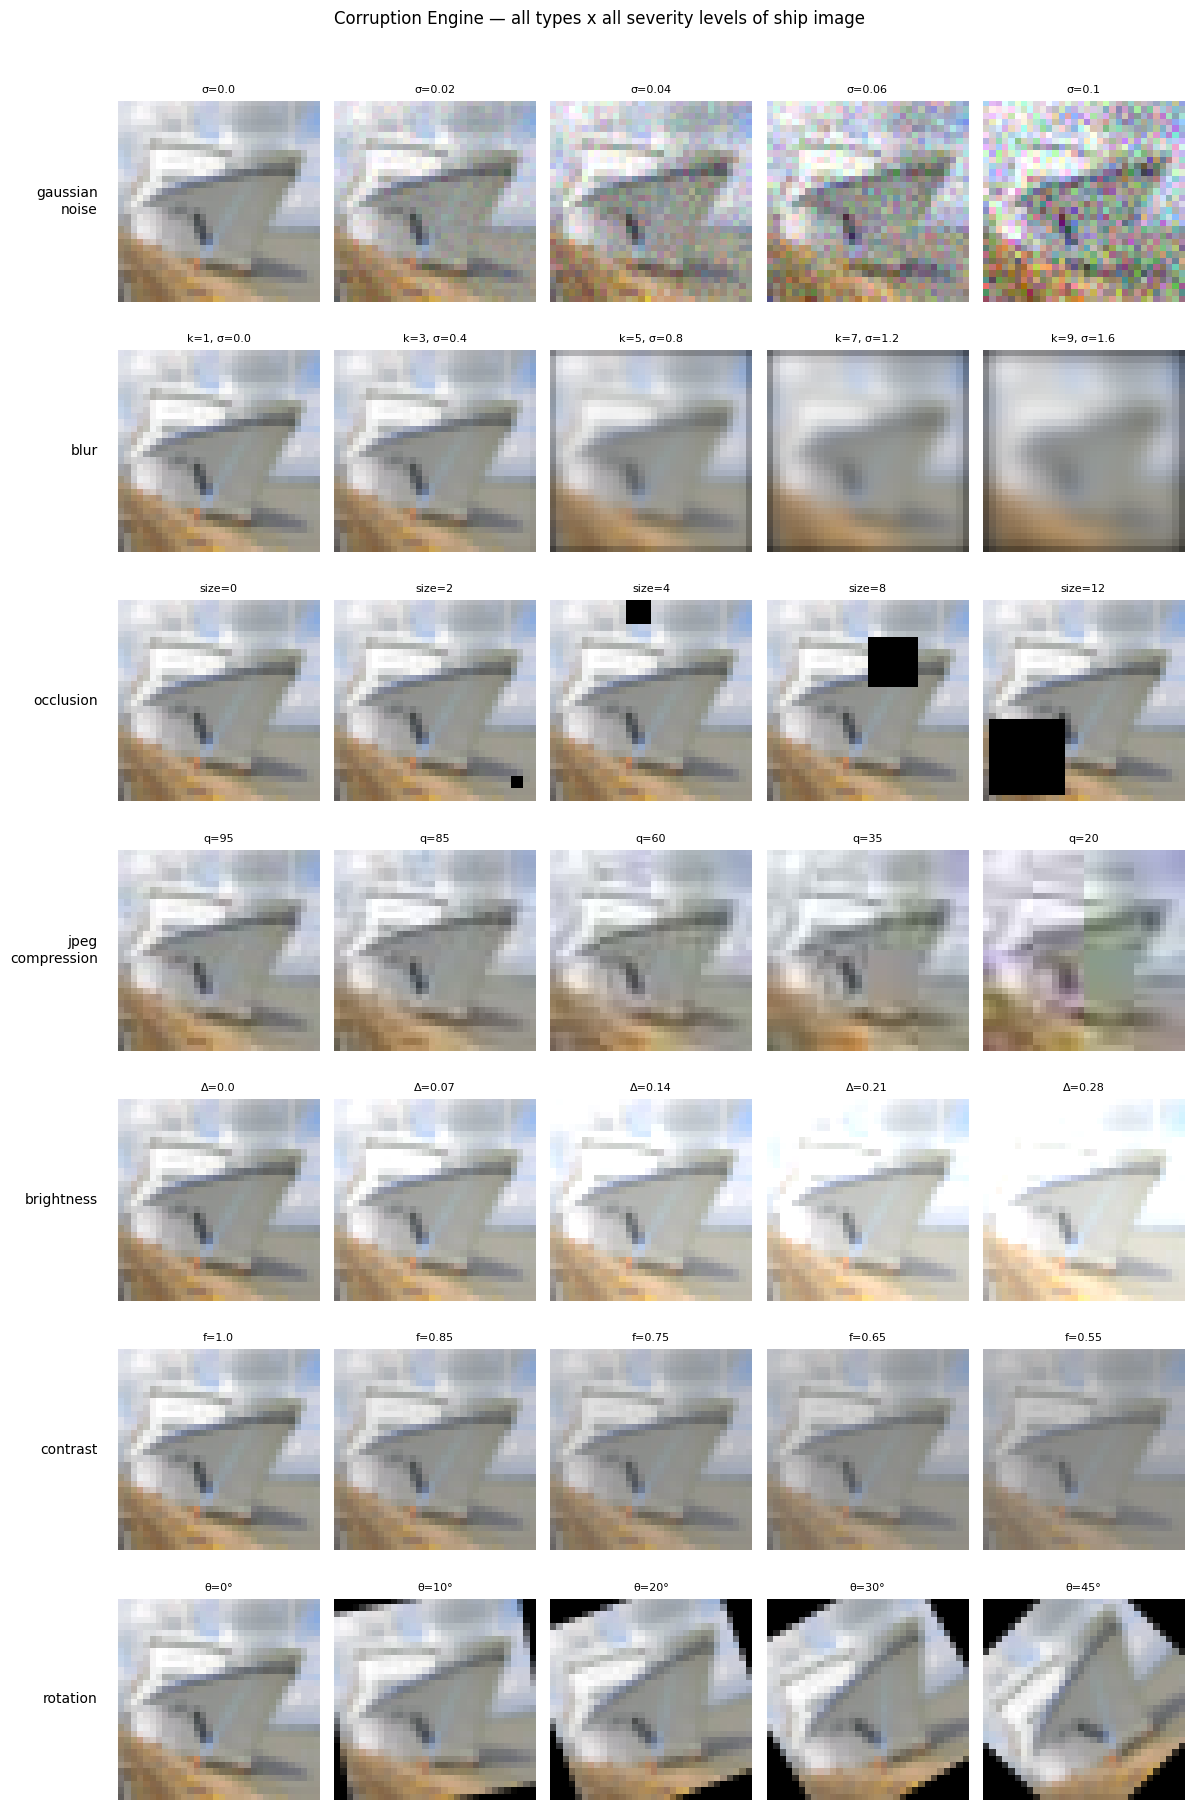

In [23]:
import torch, matplotlib.pyplot as plt
from torchvision import datasets, transforms

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.datasets.corruption_engine import apply_corruption

import importlib
import src.datasets.corruption_engine as ce

importlib.reload(ce)

DATA_PATH = os.path.join('..', 'data', 'raw')

# Load one batch from CIFAR-10
dataset = datasets.CIFAR10(root=DATA_PATH, train=True, download=True,
                           transform=transforms.ToTensor())
img, label = dataset[7569]   # shape: (3, 32, 32), float [0,1]
class_name = dataset.classes[label] # get the classname of the image

# set severities and corruptions
severities = [0, 1, 2, 3, 4]
corruptions = ["gaussian_noise", "blur", "occlusion",
               "jpeg_compression", "brightness", "contrast", "rotation"]


fig, axes = plt.subplots(len(corruptions), len(severities),
                         figsize=(12, 18))

for row, ctype in enumerate(corruptions):
    for col, sev in enumerate(severities):

        corrupted = apply_corruption(img, ctype, sev)

        axes[row, col].imshow(corrupted.permute(1, 2, 0).numpy())
        axes[row, col].axis("off")

        # ---- parameter-aware labeling ----
        if ctype == "gaussian_noise":
            label = f"σ={ [0.0, 0.02, 0.04, 0.06, 0.1][sev] }"

        elif ctype == "blur":
            label = f"k={ [1,3,5,7,9][sev] }, σ={ [0.0,0.4,0.8,1.2,1.6][sev] }"

        elif ctype == "occlusion":
            label = f"size={ [0,2,4,8,12][sev] }"

        elif ctype == "jpeg_compression":
            label = f"q={[95, 85, 60, 35, 20][sev] }"

        elif ctype == "brightness":
            label = f"Δ={ [0.0, 0.07, 0.14, 0.21, 0.28][sev] }"

        elif ctype == "contrast":
            label = f"f={ [1.0,0.85,0.75,0.65,0.55][sev] }"

        elif ctype == "rotation":
            label = f"θ={ [0,10,20,30,45][sev] }°"

        else:
            label = f"sev={sev}"

        axes[row, col].set_title(label, fontsize=8)

        # row label only once
        if col == 0:
            axes[row, col].text(
                -0.1, 0.5,
                ctype.replace("_", "\n"),
                fontsize=10,
                va="center",
                ha="right",
                transform=axes[row, col].transAxes
            )

plt.suptitle(f"Corruption Engine — all types x all severity levels of {class_name} image", y=1.01)
plt.tight_layout() # automatically adjusts spacing between images
plt.savefig("../results/imgs/corruption_grid.png", dpi=150, bbox_inches="tight")
plt.show()